<a href="https://www.kaggle.com/code/concacmemay/12345?scriptVersionId=307198286" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

### Hybrid RL + ALNS Route Optimisation Engine

| Algorithm | Role |
|---|---|
| **ALNS** | Baseline — Adaptive Large Neighbourhood Search |
| **DQN** | Constructive RL — builds routes stop-by-stop |
| **DQN→ALNS** | DQN warm-start → ALNS polish |
| **RL-ALNS** | 🏆 Proposed — RL learns which operator to pick each iteration |

**Dataset:** Solomon RC1 + RC2 (16 instances, 100 customers each)

In [1]:
# ── 1. Install & Imports ──────────────────────────────────────────────────────
!pip install numba safetensors -q

import os, glob, time, random, math
from collections import deque
from dataclasses import dataclass
from typing import List, Dict, Optional, Tuple
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numba import njit

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from safetensors.torch import save_file, load_file

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Device : {DEVICE}')
print(f'✅ PyTorch: {torch.__version__}')

✅ Device : cuda
✅ PyTorch: 2.10.0+cu128


In [2]:
# ── 2. Config ─────────────────────────────────────────────────────────────────
IN_KAGGLE  = os.path.exists('/kaggle/working')
DATA_PATH  = ('/kaggle/input/datasets/senju14/vrptw-benchmark-datasets/data/Solomon'
              if IN_KAGGLE else '/content/vrptw-benchmark/data/Solomon')
OUTPUT_DIR = '/kaggle/working' if IN_KAGGLE else '/content'
MODEL_DIR  = os.path.join(OUTPUT_DIR, 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

@dataclass
class Config:
    # ── ALNS ──────────────────────────────────────────────────────────────────
    alns_iterations:     int   = 1_200
    destroy_ratio_min:   float = 0.10
    destroy_ratio_max:   float = 0.40
    temp_control:        float = 0.05
    temp_decay:          float = 0.99975
    sigma1:              int   = 33     # new global best
    sigma2:              int   = 9      # better than current
    sigma3:              int   = 3      # accepted
    weight_decay:        float = 0.10
    segment_size:        int   = 50
    early_stop_patience: int   = 300

    # ── DQN (constructive) ────────────────────────────────────────────────────
    dqn_state_dim:       int   = 13    # 9 base + 4 TW features
    dqn_hidden:          int   = 128
    dqn_lr:              float = 1e-3
    dqn_gamma:           float = 0.95
    dqn_eps_start:       float = 0.80
    dqn_eps_end:         float = 0.05
    dqn_eps_decay:       float = 0.997
    dqn_buffer:          int   = 8_000
    dqn_batch:           int   = 64
    dqn_target_freq:     int   = 20    # sync target network every N episodes
    dqn_train_freq:      int   = 5     # train every N episodes
    dqn_episodes:        int   = 300   # max episodes (early-stopped)
    dqn_vehicle_penalty: float = 10.0  # penalty per new vehicle started

    # ── RL-ALNS (operator selection) ──────────────────────────────────────────
    # State: 14D (12 base + 2 TW-specific)
    rla_state_dim:       int   = 14
    rla_hidden:          int   = 128
    rla_lr:              float = 1e-3
    rla_gamma:           float = 0.95
    rla_eps_start:       float = 0.40
    rla_eps_end:         float = 0.01
    rla_eps_decay:       float = 0.9997
    rla_buffer:          int   = 8_000
    rla_batch:           int   = 64
    rla_target_freq:     int   = 200
    rla_train_freq:      int   = 10
    rla_reward_vehicle:  float = 5.0   # reward per vehicle eliminated
    rla_reward_cost:     float = 1.0
    rla_reward_bonus:    float = 2.0   # bonus for new global best
    rla_reward_bad:      float = -3.0  # infeasible penalty

    # ── Experiment ────────────────────────────────────────────────────────────
    n_runs:              int   = 5
    seed:                int   = 42

CFG = Config()

BKS = {
    'RC101': {'nv': 14, 'td': 1696.94}, 'RC102': {'nv': 12, 'td': 1554.75},
    'RC103': {'nv': 11, 'td': 1261.67}, 'RC104': {'nv': 10, 'td': 1135.48},
    'RC105': {'nv': 13, 'td': 1629.44}, 'RC106': {'nv': 11, 'td': 1424.73},
    'RC107': {'nv': 11, 'td': 1230.48}, 'RC108': {'nv': 10, 'td': 1139.82},
    'RC201': {'nv': 4,  'td': 1406.94}, 'RC202': {'nv': 3,  'td': 1365.64},
    'RC203': {'nv': 3,  'td': 1049.62}, 'RC204': {'nv': 3,  'td': 798.46},
    'RC205': {'nv': 4,  'td': 1297.65}, 'RC206': {'nv': 3,  'td': 1146.32},
    'RC207': {'nv': 3,  'td': 1061.14}, 'RC208': {'nv': 3,  'td': 828.14},
}
print('✅ Config ready.')

✅ Config ready.


In [3]:
# ── 3. Data Layer ─────────────────────────────────────────────────────────────
class LogisticsInstance:
    def __init__(self, raw: Dict):
        self.name     = raw['name']
        data          = raw['data']
        self.capacity = raw['capacity']
        self.coords       = data[:, 1:3]
        self.demands      = data[:, 3]
        self.ready_times  = data[:, 4]
        self.due_times    = data[:, 5]
        self.service_times= data[:, 6]
        self.horizon      = self.due_times[0]
        self.n            = len(data) - 1
        diff = self.coords[:, None, :] - self.coords[None, :, :]
        self.dist         = np.sqrt((diff**2).sum(axis=2))
        self.max_dist     = self.dist.max()
        self.tw_width     = self.due_times - self.ready_times
        self.max_tw_width = self.tw_width[1:].max() + 1e-9
        # fraction of customers with tight TW (<20% horizon) — instance difficulty
        self.tw_tight_frac = sum(
            1 for i in range(1, self.n+1)
            if self.tw_width[i] < 0.2*self.horizon
        ) / self.n

def load_datasets(base: str) -> Dict:
    datasets = {}
    for grp in ('rc1', 'rc2'):
        files = sorted(glob.glob(os.path.join(base, f'{grp}*.txt')))
        instances = []
        for path in files:
            with open(path) as f: lines = f.readlines()
            name     = lines[0].strip()
            capacity = float(lines[4].strip().split()[1])
            rows     = [list(map(float, l.split())) for l in lines[9:] if l.strip()]
            instances.append(LogisticsInstance({'name': name, 'capacity': capacity,
                                                'data': np.array(rows)}))
        datasets[grp] = instances
        print(f'  📂 {grp.upper()}: {len(instances)} instances')
    return datasets

print('Loading...')
DATASETS = load_datasets(DATA_PATH)
RC1 = DATASETS['rc1']
RC2 = DATASETS['rc2']
print(f'✅ {RC1[0].name}: n={RC1[0].n}, cap={RC1[0].capacity}, '
      f'tight_TW={RC1[0].tw_tight_frac:.0%}')

Loading...
  📂 RC1: 8 instances
  📂 RC2: 8 instances
✅ RC101: n=100, cap=200.0, tight_TW=100%


In [4]:
# ── 4. Solution Model (Numba-accelerated) ─────────────────────────────────────
@njit(cache=True)
def _route_cost(route, dist):
    c = dist[0, route[0]]
    for i in range(len(route)-1):
        c += dist[route[i], route[i+1]]
    return c + dist[route[-1], 0]

@njit(cache=True)
def _route_ok(route, demands, cap, ready, due, service, dist):
    load = 0.0
    for n in route: load += demands[n]
    if load > cap: return False
    t, prev = 0.0, 0
    for n in route:
        t += dist[prev, n]
        if t < ready[n]: t = ready[n]
        if t > due[n]:   return False
        t += service[n]; prev = n
    return True

class Plan:
    """Dispatch plan = list of routes for one day."""
    __slots__ = ('routes', 'inst', '_cost', '_ok', 'algorithm')

    def __init__(self, routes, inst, algorithm=''):
        self.routes    = [r for r in routes if r]
        self.inst      = inst
        self._cost     = None
        self._ok       = None
        self.algorithm = algorithm

    @property
    def cost(self):
        if self._cost is None:
            self._cost = sum(_route_cost(np.array(r, np.int64), self.inst.dist)
                             for r in self.routes)
        return self._cost

    @property
    def feasible(self):
        if self._ok is None:
            inst = self.inst
            self._ok = all(
                _route_ok(np.array(r, np.int64), inst.demands, inst.capacity,
                          inst.ready_times, inst.due_times, inst.service_times, inst.dist)
                for r in self.routes)
        return self._ok

    @property
    def nv(self): return len(self.routes)

    def dominates(self, other):
        if self.nv < other.nv:  return True
        return self.nv == other.nv and self.cost < other.cost

    def copy(self):
        return Plan([r[:] for r in self.routes], self.inst, self.algorithm)

    def invalidate(self):
        self._cost = self._ok = None

    # ── Business KPIs ─────────────────────────────────────────────────────────
    @property
    def on_time_rate(self):
        inst = self.inst; on = total = 0
        for route in self.routes:
            t, prev = 0.0, 0
            for n in route:
                t += inst.dist[prev, n]; t = max(t, inst.ready_times[n])
                total += 1
                if t <= inst.due_times[n]: on += 1
                t += inst.service_times[n]; prev = n
        return on / max(total, 1)

    @property
    def avg_load_util(self):
        if not self.routes: return 0.0
        return float(np.mean([sum(self.inst.demands[n] for n in r) / self.inst.capacity
                               for r in self.routes]))

    def gap_to_bks(self):
        bks = BKS.get(self.inst.name, {})
        td_gap = (self.cost - bks['td'])/bks['td']*100 if bks else None
        nv_gap = self.nv - bks['nv']                   if bks else None
        return td_gap, nv_gap

    def __repr__(self):
        td, nv = self.gap_to_bks()
        gap = f'TD {td:+.1f}% NV {nv:+d}' if td is not None else ''
        return f'Plan({self.algorithm}, nv={self.nv}, cost={self.cost:.1f}, {gap})'

print('✅ Solution model ready.')

✅ Solution model ready.


In [5]:
# ── 5. ALNS Operators ─────────────────────────────────────────────────────────
# ── Destroy ───────────────────────────────────────────────────────────────────
def _inv(plan): plan.invalidate(); return plan

def op_random_removal(plan, size):
    nodes   = [n for r in plan.routes for n in r]
    removed = random.sample(nodes, min(size, len(nodes)))
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    return _inv(plan), removed

def op_worst_removal(plan, size):
    inst = plan.inst
    gain = []
    for route in plan.routes:
        for i, n in enumerate(route):
            p  = route[i-1] if i > 0 else 0
            nx = route[i+1] if i < len(route)-1 else 0
            gain.append((inst.dist[p,n]+inst.dist[n,nx]-inst.dist[p,nx], n))
    gain.sort(reverse=True)
    removed = [n for _,n in gain[:size]]
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    return _inv(plan), removed

def op_shaw_removal(plan, size):
    inst  = plan.inst
    nodes = [n for r in plan.routes for n in r]
    if not nodes: return plan, []
    seed = random.choice(nodes); removed = [seed]; rset = {seed}
    md = inst.max_dist+1e-9; mt = max(inst.due_times-inst.ready_times)+1e-9
    while len(removed) < size:
        cands = [(n, 0.5*inst.dist[seed,n]/md
                     + 0.4*abs(inst.ready_times[seed]-inst.ready_times[n])/mt
                     + 0.1*abs(inst.demands[seed]-inst.demands[n])/inst.capacity)
                 for n in nodes if n not in rset]
        if not cands: break
        removed.append(min(cands, key=lambda x: x[1])[0])
        rset.add(removed[-1])
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    return _inv(plan), removed

def op_route_removal(plan, size):
    if len(plan.routes) <= 1: return op_random_removal(plan, size)
    removed, to_rm = [], set()
    for idx, route in sorted(enumerate(plan.routes), key=lambda x: len(x[1])):
        if len(removed)+len(route) <= size*1.5: removed.extend(route); to_rm.add(idx)
        if len(removed) >= size: break
    plan.routes = [r for i,r in enumerate(plan.routes) if i not in to_rm] or [[]]
    return _inv(plan), removed

def op_tw_urgency_removal(plan, size):
    """Remove stops with tightest delivery windows (SLA-critical)."""
    inst  = plan.inst
    nodes = [n for r in plan.routes for n in r]
    if not nodes: return plan, []
    removed = sorted(nodes, key=lambda n: inst.due_times[n]-inst.ready_times[n])[:size]
    s = set(removed)
    plan.routes = [[n for n in r if n not in s] for r in plan.routes]
    plan.routes = [r for r in plan.routes if r]
    return _inv(plan), removed

# ── Repair ────────────────────────────────────────────────────────────────────
def _check(route, inst):
    arr = np.array(route, np.int64)
    return bool(_route_ok(arr, inst.demands, inst.capacity,
                          inst.ready_times, inst.due_times, inst.service_times, inst.dist))

def _best_pos(node, route, inst):
    bc, bp = float('inf'), None
    for p in range(len(route)+1):
        prev = route[p-1] if p > 0 else 0
        nxt  = route[p]   if p < len(route) else 0
        c = inst.dist[prev,node]+inst.dist[node,nxt]-inst.dist[prev,nxt]
        if c < bc and _check(route[:p]+[node]+route[p:], inst): bc, bp = c, p
    return bc, bp

def _insert(plan, node, inst):
    bc, br, bp = float('inf'), None, None
    for ri, route in enumerate(plan.routes):
        c, p = _best_pos(node, route, inst)
        if p is not None and c < bc: bc, br, bp = c, ri, p
    if br is not None: plan.routes[br].insert(bp, node)
    else:              plan.routes.append([node])
    plan.invalidate()

def op_greedy_insertion(plan, removed):
    inst = plan.inst
    for n in sorted(removed, key=lambda n: inst.due_times[n]): _insert(plan, n, inst)
    return Plan(plan.routes, inst, plan.algorithm)

def _regret(plan, removed, k):
    inst = plan.inst; rem = removed[:]
    while rem:
        best_r, chosen, chosen_ins = -float('inf'), None, None
        for n in rem:
            opts = sorted((c,ri,p) for ri,r in enumerate(plan.routes)
                          for c,p in [_best_pos(n,r,inst)] if p is not None)
            if len(opts) >= k:   reg = sum(opts[i][0]-opts[0][0] for i in range(1,k))
            elif len(opts) >= 2: reg = opts[1][0]-opts[0][0]
            elif len(opts) == 1: reg = float('inf')
            else:                reg = -float('inf')
            if reg > best_r and opts: best_r, chosen, chosen_ins = reg, n, opts[0]
        if chosen is not None:
            _, ri, p = chosen_ins; plan.routes[ri].insert(p, chosen)
            plan.invalidate(); rem.remove(chosen)
        else:
            for n in rem: plan.routes.append([n]); break
    return Plan(plan.routes, inst, plan.algorithm)

def op_regret2(plan, removed): return _regret(plan, removed, 2)
def op_regret3(plan, removed): return _regret(plan, removed, 3)

def op_tw_greedy_insertion(plan, removed):
    """Insert tightest-window orders first to prevent SLA cascades."""
    inst = plan.inst
    for n in sorted(removed, key=lambda n: inst.due_times[n]-inst.ready_times[n]):
        _insert(plan, n, inst)
    return Plan(plan.routes, inst, plan.algorithm)

DESTROY_OPS = [op_random_removal, op_worst_removal, op_shaw_removal,
               op_route_removal,  op_tw_urgency_removal]
REPAIR_OPS  = [op_greedy_insertion, op_regret2, op_regret3, op_tw_greedy_insertion]
N_D, N_R    = len(DESTROY_OPS), len(REPAIR_OPS)
print(f'✅ Operators: {N_D} destroy × {N_R} repair = {N_D*N_R} combos')

✅ Operators: 5 destroy × 4 repair = 20 combos


In [6]:
# ── 6. Shared Helpers ─────────────────────────────────────────────────────────
def build_greedy(inst, algo='') -> Plan:
    """Earliest-deadline-first greedy construction (fastest feasible initial plan)."""
    customers = sorted(range(1, inst.n+1), key=lambda n: (inst.due_times[n], inst.ready_times[n]))
    unvisited = set(customers); routes = []
    while unvisited:
        route, node, load, t = [], 0, 0.0, 0.0
        while unvisited:
            feasible = [n for n in unvisited
                        if load+inst.demands[n] <= inst.capacity
                        and t+inst.dist[node,n] <= inst.due_times[n]]
            if not feasible: break
            nxt = min(feasible, key=lambda n: inst.dist[node,n])
            route.append(nxt); unvisited.remove(nxt)
            load += inst.demands[nxt]
            t = max(t+inst.dist[node,nxt], inst.ready_times[nxt]) + inst.service_times[nxt]
            node = nxt
        if route: routes.append(route)
    return Plan(routes, inst, algo)

def accept(current: Plan, candidate: Plan, temp: float) -> bool:
    if not candidate.feasible: return False
    if candidate.nv < current.nv:  return True
    if candidate.nv == current.nv:
        if candidate.cost < current.cost: return True
        return random.random() < math.exp(-(candidate.cost-current.cost)/max(temp, 1e-6))
    return False

def dsize(it, cfg: Config, n: int) -> int:
    ratio = cfg.destroy_ratio_max - (cfg.destroy_ratio_max-cfg.destroy_ratio_min)*(it/cfg.alns_iterations)
    return max(3, int(ratio*n))

print('✅ Helpers ready.')

✅ Helpers ready.


In [7]:
# ── 7. Neural Networks ────────────────────────────────────────────────────────
class DQNNet(nn.Module):
    """Standard DQN with LayerNorm for training stability."""
    def __init__(self, state_dim, action_dim, hidden):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.LayerNorm(hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, action_dim))
    def forward(self, x): return self.net(x)

class DuelingNet(nn.Module):
    """
    Dueling DQN — separates state-value V(s) from action-advantage A(s,a).
    Used for RL-ALNS where many operator pairs have similar value.
    Q(s,a) = V(s) + A(s,a) - mean(A)
    """
    def __init__(self, state_dim, action_dim, hidden):
        super().__init__()
        self.feature   = nn.Sequential(nn.Linear(state_dim, hidden), nn.LayerNorm(hidden), nn.ReLU())
        self.value     = nn.Sequential(nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Linear(hidden//2, 1))
        self.advantage = nn.Sequential(nn.Linear(hidden, hidden//2), nn.ReLU(), nn.Linear(hidden//2, action_dim))
    def forward(self, x):
        f = self.feature(x); v = self.value(f); a = self.advantage(f)
        return v + a - a.mean(dim=-1, keepdim=True)

class ReplayBuffer:
    def __init__(self, cap): self.buf = deque(maxlen=cap)
    def push(self, *args):   self.buf.append(args)
    def sample(self, k):
        s,a,r,ns,d = zip(*random.sample(self.buf, k))
        return (np.array(s, np.float32), np.array(a, np.int64),
                np.array(r, np.float32), np.array(ns, np.float32),
                np.array(d, np.float32))
    def __len__(self): return len(self.buf)

print('✅ Networks ready.')

✅ Networks ready.


In [8]:
# ── 8. ALNS Solver ───────────────────────────────────────────────────────────
class ALNSSolver:
    def __init__(self, inst: LogisticsInstance, cfg: Config = CFG):
        self.inst = inst; self.cfg = cfg

    def _roulette(self, w):
        p = w/w.sum(); return int(np.random.choice(len(w), p=p))

    def solve(self, init: Plan = None, seed=None) -> Tuple[Plan, List[float]]:
        if seed is not None: random.seed(seed); np.random.seed(seed)
        cfg = self.cfg
        current = init.copy() if init else build_greedy(self.inst, 'ALNS')
        current.algorithm = 'ALNS'
        best = current.copy()
        temp = cfg.temp_control * current.cost / math.log(2)
        d_w = np.ones(N_D); r_w = np.ones(N_R)
        seg_s = np.zeros((N_D,N_R)); seg_c = np.zeros((N_D,N_R))
        hist = [best.cost]; no_imp = 0

        for it in range(cfg.alns_iterations):
            di = self._roulette(d_w); ri = self._roulette(r_w)
            sz = dsize(it, cfg, self.inst.n)
            destroyed, removed = DESTROY_OPS[di](current.copy(), sz)
            candidate = REPAIR_OPS[ri](destroyed, removed)

            score = 0
            if accept(current, candidate, temp):
                if candidate.dominates(best):      best=candidate.copy(); score=cfg.sigma1; no_imp=0
                elif candidate.dominates(current): score=cfg.sigma2; no_imp=0
                else:                              score=cfg.sigma3; no_imp+=1
                current = candidate
            else: no_imp += 1

            seg_s[di,ri] += score; seg_c[di,ri] += 1
            if (it+1) % cfg.segment_size == 0:
                for d in range(N_D):
                    for r in range(N_R):
                        if seg_c[d,r] > 0:
                            avg = seg_s[d,r]/seg_c[d,r]
                            d_w[d] = d_w[d]*(1-cfg.weight_decay) + avg*cfg.weight_decay
                            r_w[r] = r_w[r]*(1-cfg.weight_decay) + avg*cfg.weight_decay
                seg_s[:]=0; seg_c[:]=0
                d_w = np.maximum(d_w, 0.1); r_w = np.maximum(r_w, 0.1)

            temp *= cfg.temp_decay; hist.append(best.cost)
            if no_imp >= cfg.early_stop_patience: break

        best.algorithm = 'ALNS'
        return best, hist

print('✅ ALNS ready.')

✅ ALNS ready.


In [9]:
# ── 9. DQN Standalone (improved) ─────────────────────────────────────────────
#
# Key improvements over original:
#  1. State 9D → 13D (+ 4 TW-specific features, all normalized 0-1)
#  2. Reward: distance penalty + vehicle-start penalty (reduces fragmentation)
#  3. Exponential epsilon decay (linear was too fast)
#  4. LayerNorm in network (stable training)
#  5. Proper DEVICE placement

class DQNSolver:
    def __init__(self, inst: LogisticsInstance, cfg: Config = CFG):
        self.inst = inst; self.cfg = cfg
        self.action_dim = inst.n + 1
        self.q   = DQNNet(cfg.dqn_state_dim, self.action_dim, cfg.dqn_hidden).to(DEVICE)
        self.q_t = DQNNet(cfg.dqn_state_dim, self.action_dim, cfg.dqn_hidden).to(DEVICE)
        self.q_t.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=cfg.dqn_lr)
        self.buf = ReplayBuffer(cfg.dqn_buffer)
        self.eps = cfg.dqn_eps_start

    def _state(self, node, visited, load, t):
        inst = self.inst
        unvisited = inst.n - len(visited)
        feasible  = [n for n in range(1, inst.n+1)
                     if n not in visited
                     and load+inst.demands[n] <= inst.capacity
                     and t+inst.dist[node,n] <= inst.due_times[n]]
        n_f = len(feasible)
        # TW features
        if feasible:
            slacks = [inst.due_times[n]-(t+inst.dist[node,n]) for n in feasible]
            min_sl       = min(slacks)/max(inst.horizon,1)
            avg_sl       = (sum(slacks)/n_f)/max(inst.horizon,1)
            urgent_frac  = sum(1 for s in slacks if s < 0.1*inst.horizon)/max(n_f,1)
            avg_tw_w     = (sum(inst.tw_width[n] for n in feasible)/n_f)/max(inst.max_tw_width,1)
        else:
            min_sl = avg_sl = urgent_frac = avg_tw_w = 0.0
        return np.array([
            load/inst.capacity,                    # 0  load ratio
            t/max(inst.horizon,1),                 # 1  time progress
            len(visited)/inst.n,                   # 2  visited ratio
            (inst.capacity-load)/inst.capacity,    # 3  remaining cap
            unvisited/inst.n,                      # 4  unvisited ratio
            n_f/max(unvisited,1),                  # 5  feasibility ratio
            inst.coords[node,0]/100,               # 6  x
            inst.coords[node,1]/100,               # 7  y
            inst.demands[node]/inst.capacity,      # 8  demand ratio
            min_sl,                                # 9  min TW slack [NEW]
            avg_sl,                                # 10 avg TW slack [NEW]
            urgent_frac,                           # 11 urgent fraction [NEW]
            avg_tw_w,                              # 12 avg TW width [NEW]
        ], dtype=np.float32)

    def _actions(self, node, visited, load, t):
        inst = self.inst; acts = [0]
        for n in range(1, inst.n+1):
            if (n not in visited
                    and load+inst.demands[n] <= inst.capacity
                    and t+inst.dist[node,n]  <= inst.due_times[n]):
                acts.append(n)
        return acts

    def _select(self, state, feasible):
        if random.random() < self.eps: return random.choice(feasible)
        with torch.no_grad():
            q = self.q(torch.tensor(state).unsqueeze(0).to(DEVICE)).cpu().numpy()[0]
        return max(feasible, key=lambda a: q[a])

    def _train(self):
        if len(self.buf) < self.cfg.dqn_batch: return
        s,a,r,ns,d = self.buf.sample(self.cfg.dqn_batch)
        s  = torch.tensor(s).to(DEVICE);  a = torch.tensor(a, dtype=torch.long).to(DEVICE)
        r  = torch.tensor(r).to(DEVICE); ns = torch.tensor(ns).to(DEVICE)
        d  = torch.tensor(d).to(DEVICE)
        qp = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            tgt = r + self.cfg.dqn_gamma * self.q_t(ns).max(1)[0] * (1-d)
        loss = F.mse_loss(qp, tgt)
        self.opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 1.0)
        self.opt.step()

    def _episode(self):
        inst = self.inst; visited = set(); routes = []; transitions = []
        while len(visited) < inst.n:
            route, node, load, t = [], 0, 0.0, 0.0
            is_new_route = True
            while True:
                state   = self._state(node, visited, load, t)
                feasible= self._actions(node, visited, load, t)
                if len(feasible) == 1: break
                action  = self._select(state, feasible)
                if action == 0: break
                d = inst.dist[node, action]
                # reward = -distance - vehicle_penalty_if_first_stop_of_route
                reward  = -d/max(inst.max_dist,1)
                if is_new_route and len(routes) > 0:
                    # penalise starting yet another vehicle
                    reward -= self.cfg.dqn_vehicle_penalty / inst.n
                is_new_route = False
                load += inst.demands[action]
                t = max(t+d, inst.ready_times[action]) + inst.service_times[action]
                visited.add(action); route.append(action)
                ns   = self._state(action, visited, load, t)
                done = (len(visited) == inst.n)
                transitions.append((state, action, reward, ns, float(done)))
                node = action
            if route: routes.append(route)
        return Plan(routes, inst, 'DQN'), transitions

    def solve(self, seed=None) -> Tuple[Plan, List[float]]:
        if seed is not None: random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        cfg = self.cfg; best = None; best_cost = float('inf'); hist = []
        self.eps = cfg.dqn_eps_start
        n_ep = max(50, cfg.alns_iterations // self.inst.n)

        for ep in range(n_ep):
            plan, transitions = self._episode()
            if plan.feasible and transitions:
                bonus = max(0,(best_cost-plan.cost)/best_cost*10) if best_cost<float('inf') else 1.0
                s,a,r,ns,d = transitions[-1]; transitions[-1] = (s,a,r+bonus,ns,d)
                if plan.cost < best_cost: best_cost=plan.cost; best=plan.copy()
            for tr in transitions: self.buf.push(*tr)
            if ep % cfg.dqn_train_freq == 0:
                for _ in range(min(5, len(self.buf)//max(cfg.dqn_batch,1))): self._train()
            if ep % cfg.dqn_target_freq == 0: self.q_t.load_state_dict(self.q.state_dict())
            self.eps = max(cfg.dqn_eps_end, self.eps*cfg.dqn_eps_decay)
            hist.append(best_cost if best_cost<float('inf') else float('nan'))

        if best is None: best = build_greedy(self.inst, 'DQN')
        best.algorithm = 'DQN'
        return best, hist

    def save(self, path): save_file({k:v.cpu() for k,v in self.q.state_dict().items()}, path)
    def load(self, path): self.q.load_state_dict(load_file(path)); self.q_t.load_state_dict(self.q.state_dict())

print('✅ DQN solver ready.')

✅ DQN solver ready.


In [10]:
# ── 10. RL-ALNS — Main Contribution ──────────────────────────────────────────
#
# Architecture:
#   • RL agent (Dueling Double DQN) observes the CURRENT SOLUTION STATE
#   • Selects one of N_D×N_R operator pairs at each ALNS iteration
#   • ALNS framework guarantees feasibility via SA acceptance
#   • RL learns WHICH operator is most effective GIVEN the current search context
#
# Why better than vanilla ALNS:
#   • ALNS uses fixed roulette weights (adapted per-segment, not per-iteration)
#   • RL adapts in real-time based on solution state (cost gap, TW slack, temp, etc.)
#   • Especially effective when the search landscape changes (e.g. plateau vs improvement)

class RLALNSSolver:
    def __init__(self, inst: LogisticsInstance, cfg: Config = CFG, mode='double_dqn'):
        self.inst = inst; self.cfg = cfg; self.mode = mode
        self.action_dim = N_D * N_R
        Net = DuelingNet if mode=='double_dqn' else DQNNet
        self.q   = Net(cfg.rla_state_dim, self.action_dim, cfg.rla_hidden).to(DEVICE)
        self.q_t = Net(cfg.rla_state_dim, self.action_dim, cfg.rla_hidden).to(DEVICE)
        self.q_t.load_state_dict(self.q.state_dict())
        self.opt = optim.Adam(self.q.parameters(), lr=cfg.rla_lr)
        self.buf = ReplayBuffer(cfg.rla_buffer)
        self.eps = cfg.rla_eps_start

    def _state(self, current: Plan, best: Plan, it, temp, d_w, r_w, improvements):
        inst = self.inst; cfg = self.cfg
        imp_rate  = sum(improvements)/len(improvements) if improvements else 0.0
        cost_gap  = min((current.cost-best.cost)/max(best.cost,1), 1.0)
        nv_ratio  = current.nv/max(self._init_nv, 1)
        progress  = it/cfg.alns_iterations
        lens  = [len(r) for r in current.routes] or [0]
        loads = [sum(inst.demands[n] for n in r) for r in current.routes] or [0]
        route_bal = float(np.std(lens)/max(np.mean(lens),1)) if len(lens)>1 else 0.0
        load_bal  = float(np.std(loads)/max(inst.capacity,1))
        T0        = cfg.temp_control*best.cost/math.log(2)
        temp_norm = min(temp/max(T0,1e-6), 1.0)
        dp=d_w/d_w.sum(); rp=r_w/r_w.sum()
        # TW-specific features
        tw_tight  = inst.tw_tight_frac                         # instance difficulty
        tw_slack  = self._avg_tw_slack(current)               # current solution slack
        return np.array([
            cost_gap, nv_ratio, progress,
            imp_rate, 1-imp_rate,
            min(route_bal,1.0), min(load_bal,1.0),
            temp_norm,
            dp.max(), dp.min(), rp.max(), rp.min(),
            tw_tight,     # [NEW]
            tw_slack,     # [NEW]
        ], dtype=np.float32)

    def _avg_tw_slack(self, plan: Plan) -> float:
        inst = plan.inst; total_slack = 0.0; n_stops = 0
        for route in plan.routes:
            t, prev = 0.0, 0
            for n in route:
                t += inst.dist[prev, n]; t = max(t, inst.ready_times[n])
                total_slack += inst.due_times[n] - t  # remaining TW at arrival
                t += inst.service_times[n]; prev = n; n_stops += 1
        return (total_slack/n_stops)/max(inst.horizon,1) if n_stops else 0.0

    def _act(self, state):
        if random.random() < self.eps: return random.randrange(self.action_dim)
        with torch.no_grad():
            s = torch.tensor(state).unsqueeze(0).to(DEVICE)
            return int(self.q(s).argmax().item())

    def _decode(self, action): return action//N_R, action%N_R

    def _reward(self, current: Plan, candidate: Plan, best: Plan) -> float:
        """Hierarchical reward: vehicle reduction > cost reduction."""
        cfg = self.cfg
        if not candidate.feasible: return cfg.rla_reward_bad
        r  = (current.nv - candidate.nv) * cfg.rla_reward_vehicle
        r += (current.cost - candidate.cost)/max(current.cost,1)*100*cfg.rla_reward_cost
        if candidate.dominates(best): r += cfg.rla_reward_bonus
        return float(r)

    def _train(self):
        if len(self.buf) < self.cfg.rla_batch: return
        s,a,r,ns,d = self.buf.sample(self.cfg.rla_batch)
        s  = torch.tensor(s).to(DEVICE); a = torch.tensor(a, dtype=torch.long).to(DEVICE)
        r  = torch.tensor(r).to(DEVICE); ns= torch.tensor(ns).to(DEVICE)
        d  = torch.tensor(d).to(DEVICE)
        qp = self.q(s).gather(1, a.unsqueeze(1)).squeeze(1)
        with torch.no_grad():
            if self.mode == 'double_dqn':  # Double DQN: online net selects, target net evaluates
                a_next = self.q(ns).argmax(1)
                q_next = self.q_t(ns).gather(1, a_next.unsqueeze(1)).squeeze(1)
            else:
                q_next = self.q_t(ns).max(1)[0]
            tgt = r + self.cfg.rla_gamma * q_next * (1-d)
        loss = F.mse_loss(qp, tgt)
        self.opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(self.q.parameters(), 1.0)
        self.opt.step()

    def solve(self, seed=None) -> Tuple[Plan, List[float]]:
        if seed is not None: random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
        cfg = self.cfg
        current = build_greedy(self.inst, 'RL-ALNS'); best = current.copy()
        self._init_nv = current.nv
        temp = cfg.temp_control * current.cost / math.log(2)
        d_w = np.ones(N_D); r_w = np.ones(N_R)
        seg_s = np.zeros((N_D,N_R)); seg_c = np.zeros((N_D,N_R))
        improvements = deque(maxlen=50); hist = [best.cost]; no_imp = 0
        self.eps = cfg.rla_eps_start

        for it in range(cfg.alns_iterations):
            state  = self._state(current, best, it, temp, d_w, r_w, improvements)
            action = self._act(state); di, ri = self._decode(action)
            sz     = dsize(it, cfg, self.inst.n)
            destroyed, removed = DESTROY_OPS[di](current.copy(), sz)
            candidate = REPAIR_OPS[ri](destroyed, removed)
            reward    = self._reward(current, candidate, best)
            alns_score= 0

            if accept(current, candidate, temp):
                improved = candidate.dominates(current)
                improvements.append(1 if improved else 0)
                if candidate.dominates(best):  best=candidate.copy(); alns_score=cfg.sigma1; no_imp=0
                elif improved:                 alns_score=cfg.sigma2; no_imp=0
                else:                          alns_score=cfg.sigma3; no_imp+=1
                current = candidate
            else: improvements.append(0); no_imp += 1

            # ALNS adaptive weight update (still runs alongside RL)
            seg_s[di,ri] += alns_score; seg_c[di,ri] += 1
            if (it+1) % cfg.segment_size == 0:
                for d in range(N_D):
                    for r in range(N_R):
                        if seg_c[d,r]>0:
                            avg = seg_s[d,r]/seg_c[d,r]
                            d_w[d]=d_w[d]*(1-cfg.weight_decay)+avg*cfg.weight_decay
                            r_w[r]=r_w[r]*(1-cfg.weight_decay)+avg*cfg.weight_decay
                seg_s[:]=0; seg_c[:]=0
                d_w=np.maximum(d_w,0.1); r_w=np.maximum(r_w,0.1)

            ns = self._state(current, best, it+1, temp, d_w, r_w, improvements)
            self.buf.push(state, action, reward, ns, float(it==cfg.alns_iterations-1))
            if it % cfg.rla_train_freq  == 0: self._train()
            if it % cfg.rla_target_freq == 0: self.q_t.load_state_dict(self.q.state_dict())
            self.eps = max(cfg.rla_eps_end, self.eps*cfg.rla_eps_decay)
            temp *= cfg.temp_decay; hist.append(best.cost)
            if no_imp >= cfg.early_stop_patience: break

        best.algorithm = 'RL-ALNS'
        return best, hist

    def save(self, path): save_file({k:v.cpu() for k,v in self.q.state_dict().items()}, path)
    def load(self, path): self.q.load_state_dict(load_file(path)); self.q_t.load_state_dict(self.q.state_dict())

print('✅ RL-ALNS solver ready.')

✅ RL-ALNS solver ready.


In [11]:
# ── 11. DQN→ALNS Hybrid (fixed) ───────────────────────────────────────────────
#
# Fix from v1:
#   OLD: DQN always provides warm-start → ALNS (even when DQN is worse than greedy)
#   NEW: Compare DQN init vs greedy init → take the BETTER one for ALNS
#
# Rationale:
#   DQN with limited episodes (300) sometimes produces 27+ vehicle solutions.
#   Starting ALNS from a bad point wastes iterations recovering ground.
#   Fallback ensures DQN→ALNS is ALWAYS at least as good as ALNS alone.

class DQNALNSSolver:
    def __init__(self, inst: LogisticsInstance, cfg: Config = CFG):
        self.inst = inst; self.cfg = cfg
        self.dqn  = DQNSolver(inst, cfg)
        self.alns = ALNSSolver(inst, cfg)

    def solve(self, seed=None, verbose=False) -> Tuple[Plan, Dict]:
        # Phase 1 — DQN constructor
        if verbose: print('  [Phase 1] DQN...')
        dqn_plan, dqn_hist = self.dqn.solve(seed=seed)

        # Fallback: compare DQN vs greedy, use whichever is better
        greedy_plan = build_greedy(self.inst, 'greedy')
        if dqn_plan.feasible and dqn_plan.dominates(greedy_plan):
            warm_start = dqn_plan
            if verbose: print(f'  → DQN warm-start used (nv={dqn_plan.nv}, cost={dqn_plan.cost:.1f})')
        else:
            warm_start = greedy_plan
            if verbose: print(f'  → Greedy fallback (DQN nv={dqn_plan.nv} vs greedy nv={greedy_plan.nv})')

        # Phase 2 — ALNS from best available warm-start
        if verbose: print('  [Phase 2] ALNS...')
        alns_plan, alns_hist = self.alns.solve(init=warm_start, seed=seed)

        alns_plan.algorithm = 'DQN→ALNS'
        return alns_plan, {'dqn': dqn_hist, 'alns': alns_hist, 'dqn_plan': dqn_plan,
                           'used_dqn_start': dqn_plan.feasible and dqn_plan.dominates(greedy_plan)}

    def save(self, path): self.dqn.save(path)
    def load(self, path): self.dqn.load(path)

print('✅ DQN→ALNS solver ready.')

✅ DQN→ALNS solver ready.


In [12]:
# ── 12. Multi-Run Benchmark ───────────────────────────────────────────────────

ALGORITHMS = {
    'ALNS':     lambda inst, cfg: ALNSSolver(inst, cfg),
    'DQN':      lambda inst, cfg: DQNSolver(inst, cfg),
    'DQN→ALNS': lambda inst, cfg: DQNALNSSolver(inst, cfg),
    'RL-ALNS':  lambda inst, cfg: RLALNSSolver(inst, cfg),
}

def run_benchmark(instances: List[LogisticsInstance],
                  algorithms: List[str] = list(ALGORITHMS.keys()),
                  cfg: Config = CFG,
                  result_path: str = None) -> pd.DataFrame:
    """
    Run n_runs × algorithms × instances.
    Results saved after every combo (checkpoint/resume).
    """
    if result_path is None:
        result_path = os.path.join(OUTPUT_DIR, 'benchmark.csv')

    done = set()
    if os.path.exists(result_path):
        ex = pd.read_csv(result_path)
        done = set(zip(ex['Instance'], ex['Algorithm']))
        print(f'  Resuming — {len(done)} combos done')

    total = len(instances) * len(algorithms)
    print(f'  Total combos: {total} | n_runs: {cfg.n_runs}')
    print('='*60)

    for inst in instances:
        ds = 'RC1' if 'RC1' in inst.name or inst.name.startswith('RC1') else 'RC2'
        for algo_name in algorithms:
            if (inst.name, algo_name) in done:
                print(f'  ⏭ Skip {inst.name} — {algo_name}'); continue

            print(f'\n  [{inst.name}] {algo_name}')
            run_nvs, run_costs, run_times = [], [], []

            for run in range(cfg.n_runs):
                seed = cfg.seed + run
                t0   = time.time()
                solver = ALGORITHMS[algo_name](inst, cfg)
                if algo_name == 'DQN→ALNS':
                    plan, meta = solver.solve(seed=seed)
                else:
                    plan, _ = solver.solve(seed=seed)
                elapsed = time.time() - t0

                run_nvs.append(plan.nv)
                run_costs.append(plan.cost)
                run_times.append(elapsed)
                print(f'    run {run+1}/{cfg.n_runs}: nv={plan.nv} cost={plan.cost:.1f} ({elapsed:.1f}s)')

                # Save model on first run
                if run == 0 and hasattr(solver, 'save'):
                    solver.save(os.path.join(MODEL_DIR, f'{algo_name.replace("→","_")}_{inst.name}.safetensors'))

            bks = BKS.get(inst.name, {})
            avg_cost = np.mean(run_costs); avg_nv = np.mean(run_nvs)
            td_gap   = (avg_cost-bks['td'])/bks['td']*100 if bks.get('td') else None
            nv_diff  = avg_nv - bks['nv']                  if bks.get('nv') else None

            row = pd.DataFrame([{
                'Dataset':   ds,
                'Instance':  inst.name,
                'Algorithm': algo_name,
                'NV_mean':   round(avg_nv, 2),
                'NV_std':    round(np.std(run_nvs), 2),
                'NV_diff':   round(nv_diff, 2) if nv_diff is not None else None,
                'TD_mean':   round(avg_cost, 2),
                'TD_std':    round(np.std(run_costs), 2),
                'Gap%':      round(td_gap, 2) if td_gap is not None else None,
                'Time_s':    round(np.mean(run_times), 1),
            }])
            row.to_csv(result_path, mode='a', header=not os.path.exists(result_path), index=False)
            print(f'    → nv={avg_nv:.1f}±{np.std(run_nvs):.1f}  '
                  f'td={avg_cost:.1f}±{np.std(run_costs):.1f}  gap={td_gap:+.1f}%')

    return pd.read_csv(result_path)

print('✅ Benchmark runner ready.')

✅ Benchmark runner ready.


In [13]:
# ── 13. Results Table (Paper-style) ──────────────────────────────────────────

def print_paper_table(df: pd.DataFrame):
    """Academic summary table with mean ± std per dataset."""
    summary = (
        df.groupby(['Dataset','Algorithm'])
          .agg(
              NV    =('NV_mean','mean'),
              NV_std=('NV_std','mean'),
              NV_d  =('NV_diff','mean'),
              TD    =('TD_mean','mean'),
              TD_std=('TD_std','mean'),
              Gap   =('Gap%','mean'),
              Time  =('Time_s','mean'),
          ).round(2).reset_index()
    )

    print(f'\n{"─"*78}')
    print(f'{"Dataset":<6} {"Algorithm":<12} {"NV":>8} {"NV±":>6} {"NV vs BKS":>10}'
          f'{"TD":>10} {"TD±":>7} {"Gap%":>8} {"Time":>7}')
    print(f'{"─"*78}')
    prev_ds = ''
    for _, r in summary.iterrows():
        if r['Dataset'] != prev_ds and prev_ds: print(f'{"─"*78}')
        prev_ds = r['Dataset']
        nv_d = f"{r['NV_d']:+.1f}" if pd.notna(r['NV_d']) else '—'
        gap  = f"{r['Gap']:+.1f}%" if pd.notna(r['Gap'])   else '—'
        print(f"{r['Dataset']:<6} {r['Algorithm']:<12} "
              f"{r['NV']:>8.1f} {r['NV_std']:>6.1f} {nv_d:>10}"
              f"{r['TD']:>10.1f} {r['TD_std']:>7.1f} {gap:>8} {r['Time']:>6.1f}s")
    print(f'{"─"*78}')
    print('Note: NV vs BKS = avg_NV - BKS_NV. Negative Gap% = below BKS distance.')
    print('      Negative Gap% with NV_diff>0 means extra vehicle enables shorter routes.')


def per_instance_table(df: pd.DataFrame, dataset: str = 'RC1'):
    """Detailed per-instance breakdown for the appendix."""
    sub = df[df['Dataset']==dataset].copy()
    pivot = sub.pivot_table(
        index='Instance',
        columns='Algorithm',
        values=['NV_mean','TD_mean','Gap%'],
        aggfunc='mean'
    ).round(2)
    print(f'\n── {dataset} per-instance ──')
    print(pivot.to_string())
    return pivot

print('✅ Table utilities ready.')

✅ Table utilities ready.


In [14]:
# ── 14. Visualisation ─────────────────────────────────────────────────────────
COLORS = {'ALNS':'#5f5fae','DQN':'#e8593c','DQN→ALNS':'#f2a623','RL-ALNS':'#1d9e75'}

def plot_routes(plan: Plan, title='', figsize=(11,8)):
    ROUTE_COLORS = ['#E63946','#2A9D8F','#E9C46A','#264653','#F4A261',
                    '#A8DADC','#457B9D','#6A4C93','#F72585','#4CC9F0',
                    '#80B918','#FF9F1C','#8338EC','#3A86FF','#CBFF8C']
    inst = plan.inst; fig, ax = plt.subplots(figsize=figsize)
    depot = inst.coords[0]
    ax.scatter(*depot, s=220, c='black', marker='s', zorder=5)
    ax.annotate('DEPOT', depot, fontsize=8, ha='center', va='bottom', fontweight='bold')
    for i, route in enumerate(plan.routes):
        col   = ROUTE_COLORS[i % len(ROUTE_COLORS)]
        stops = [0]+route+[0]
        xs = [inst.coords[n,0] for n in stops]
        ys = [inst.coords[n,1] for n in stops]
        ax.plot(xs, ys, '-o', color=col, lw=1.5, ms=4, alpha=0.8, label=f'V{i+1}')
    td, nv = plan.gap_to_bks()
    gap_str = f' | BKS: TD {td:+.1f}% NV {nv:+d}' if td is not None else ''
    ax.set_title(title or f'{plan.algorithm} — {inst.name}\n'
                 f'{plan.nv} vehicles · {plan.cost:.1f} dist · '
                 f'on-time: {plan.on_time_rate:.1%}{gap_str}',
                 fontsize=11, fontweight='bold')
    ax.legend(loc='upper right', fontsize=6, ncol=3, framealpha=0.9)
    ax.grid(alpha=0.2); plt.tight_layout(); plt.show()


def plot_comparison(plans: List[Plan], metric='cost'):
    """Bar chart comparison across algorithms."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    metrics   = {'cost': ('Total Distance', lambda p: p.cost),
                 'nv':   ('Vehicles Used',  lambda p: p.nv)}
    for ax, (met, (label, fn)) in zip(axes, metrics.items()):
        vals  = [fn(p) for p in plans]
        algos = [p.algorithm for p in plans]
        cols  = [COLORS.get(a, '#aaa') for a in algos]
        bars  = ax.bar(algos, vals, color=cols, alpha=0.85, edgecolor='white')
        for bar, v in zip(bars, vals): ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                                               f'{v:.1f}', ha='center', va='bottom', fontsize=9)
        bks = BKS.get(plans[0].inst.name, {})
        if bks and met == 'cost':    ax.axhline(bks['td'], ls='--', c='gray', lw=1.2, label='BKS')
        elif bks and met == 'nv':    ax.axhline(bks['nv'], ls='--', c='gray', lw=1.2, label='BKS')
        ax.set_title(f'{label} — {plans[0].inst.name}', fontweight='bold')
        ax.set_ylabel(label); ax.legend(); ax.grid(axis='y', alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_convergence(histories: Dict[str, List[float]]):
    """Convergence curves for all algorithms."""
    fig, ax = plt.subplots(figsize=(10, 4))
    for algo, hist in histories.items():
        ax.plot(hist, label=algo, color=COLORS.get(algo,'#aaa'), lw=1.8, alpha=0.9)
    ax.set_xlabel('Iteration'); ax.set_ylabel('Best Cost')
    ax.set_title('Convergence Comparison', fontweight='bold')
    ax.legend(); ax.grid(alpha=0.2); plt.tight_layout(); plt.show()


def plot_dashboard(df: pd.DataFrame):
    metrics = [('TD_mean','Total Distance','↓'), ('NV_mean','Vehicles Used','↓'),
               ('Gap%','TD Gap vs BKS (%)','↓')]
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    for row_idx, ds in enumerate(['RC1','RC2']):
        for col_idx, (metric, label, arrow) in enumerate(metrics):
            ax  = axes[row_idx][col_idx]
            sub = df[df['Dataset']==ds]
            insts = sub['Instance'].unique()
            x, w  = np.arange(len(insts)), 0.20
            algos = [a for a in COLORS if a in sub['Algorithm'].values]
            for j, algo in enumerate(algos):
                vals = [sub[sub['Instance']==i][metric].mean() for i in insts]
                ax.bar(x+j*w, vals, w, label=algo, color=COLORS[algo], alpha=0.85, edgecolor='white')
            ax.set_xticks(x+w*1.5)
            ax.set_xticklabels([i[-3:] for i in insts], fontsize=8)
            ax.set_title(f'{ds} — {label} ({arrow})', fontsize=9, fontweight='bold')
            ax.set_ylabel(metric, fontsize=8)
            ax.grid(axis='y', alpha=0.3)
            if row_idx==0 and col_idx==0: ax.legend(fontsize=8)
    plt.suptitle('Algorithm Comparison Dashboard', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR,'dashboard.png'), dpi=150, bbox_inches='tight')
    plt.show()

print('✅ Visualisation ready.')

✅ Visualisation ready.


Smoke test on RC101 (n=100)

  ALNS         nv= 16  cost=  1712.1  feasible=True  BKS: TD +0.9% NV +2  (34.1s)
  DQN          nv= 42  cost=  4123.4  feasible=True  BKS: TD +143.0% NV +28  (9.5s)
  [Phase 1] DQN...
  → Greedy fallback (DQN nv=42 vs greedy nv=27)
  [Phase 2] ALNS...
  DQN→ALNS     nv= 16  cost=  1712.1  feasible=True  BKS: TD +0.9% NV +2  (33.7s)
  RL-ALNS      nv= 15  cost=  1785.8  feasible=True  BKS: TD +5.2% NV +1  (15.9s)

✓ Smoke test passed


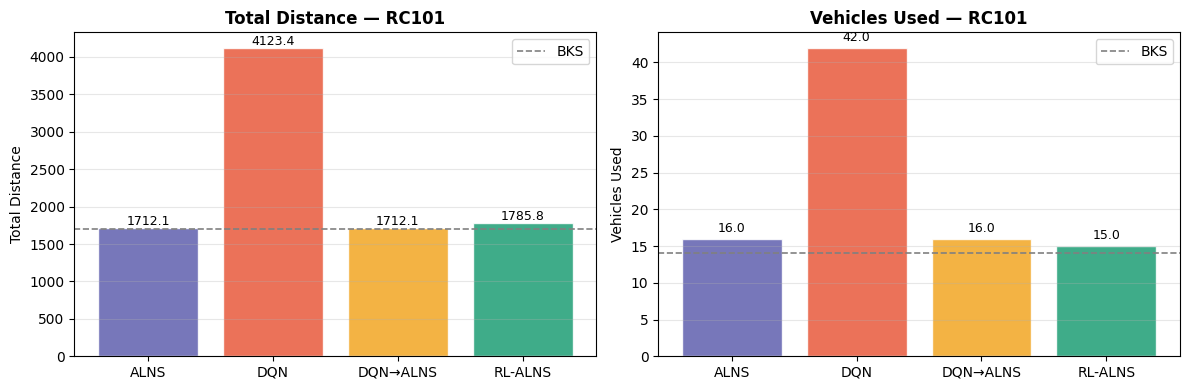

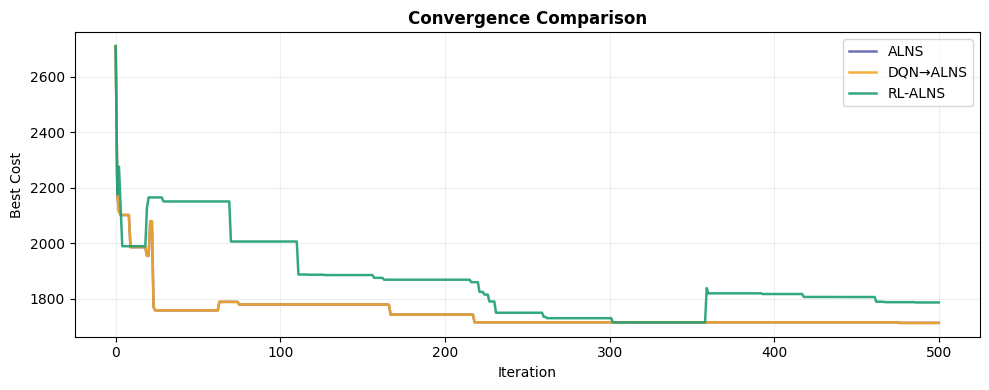

In [15]:
# ── 15. Smoke Test (RC101, 1 run) ─────────────────────────────────────────────
inst = RC1[0]  # RC101
print(f'Smoke test on {inst.name} (n={inst.n})\n')

smoke_cfg = Config(alns_iterations=500, early_stop_patience=200, n_runs=1, dqn_episodes=100)
histories  = {}
plans      = []

for algo_name, builder in ALGORITHMS.items():
    t0     = time.time()
    solver = builder(inst, smoke_cfg)
    if algo_name == 'DQN→ALNS':
        plan, meta = solver.solve(seed=42, verbose=True)
        histories[algo_name] = meta['alns']
    else:
        plan, hist = solver.solve(seed=42)
        histories[algo_name] = hist
    elapsed = time.time()-t0
    td, nv  = plan.gap_to_bks()
    plans.append(plan)
    print(f'  {algo_name:<12} nv={plan.nv:>3}  cost={plan.cost:>8.1f}  '
          f'feasible={plan.feasible}  BKS: TD {td:+.1f}% NV {nv:+d}  ({elapsed:.1f}s)')

print('\n✓ Smoke test passed')
plot_comparison(plans)
plot_convergence({k:v for k,v in histories.items() if k != 'DQN'})

In [16]:
# ── 16. Full Benchmark (RC1 + RC2, 4 algorithms, n_runs runs) ─────────────────
# ⚠️  Runtime estimate on T4 GPU:
#   n_runs=1 → ~45 min   |   n_runs=3 → ~2 hrs   |   n_runs=5 → ~4 hrs

ALL = RC1 + RC2
ALGOS = ['ALNS', 'DQN', 'DQN→ALNS', 'RL-ALNS']

df = run_benchmark(ALL, algorithms=ALGOS, cfg=CFG)
print_paper_table(df)

  Total combos: 64 | n_runs: 5

  [RC101] ALNS
    run 1/5: nv=15 cost=1739.5 (76.9s)
    run 2/5: nv=15 cost=1641.3 (82.1s)
    run 3/5: nv=16 cost=1682.8 (84.3s)
    run 4/5: nv=16 cost=1674.5 (99.4s)
    run 5/5: nv=15 cost=1721.2 (89.2s)
    → nv=15.4±0.5  td=1691.9±34.8  gap=-0.3%

  [RC101] DQN
    run 1/5: nv=42 cost=4156.5 (1.5s)
    run 2/5: nv=42 cost=4137.2 (1.5s)
    run 3/5: nv=47 cost=4345.0 (1.7s)
    run 4/5: nv=39 cost=4025.2 (1.5s)
    run 5/5: nv=51 cost=4559.7 (1.7s)
    → nv=44.2±4.3  td=4244.7±188.1  gap=+150.1%

  [RC101] DQN→ALNS
    run 1/5: nv=15 cost=1739.5 (80.2s)
    run 2/5: nv=15 cost=1641.3 (84.3s)
    run 3/5: nv=16 cost=1682.8 (84.7s)
    run 4/5: nv=16 cost=1674.5 (100.2s)
    run 5/5: nv=15 cost=1721.2 (89.9s)
    → nv=15.4±0.5  td=1691.9±34.8  gap=-0.3%

  [RC101] RL-ALNS
    run 1/5: nv=16 cost=1687.7 (75.1s)
    run 2/5: nv=15 cost=1702.0 (76.4s)
    run 3/5: nv=16 cost=1707.0 (93.6s)
    run 4/5: nv=16 cost=1692.3 (60.6s)
    run 5/5: nv=16 cost=


──────────────────────────────────────────────────────────────────────────────
Dataset Algorithm          NV    NV±  NV vs BKS        TD     TD±     Gap%    Time
──────────────────────────────────────────────────────────────────────────────
RC1    ALNS             12.7    0.2       +1.2    1401.6    17.7    +1.6%   83.5s
RC1    DQN              34.5    2.0      +23.1    4069.4   127.3  +199.8%    1.5s
RC1    DQN→ALNS         12.7    0.2       +1.2    1401.6    17.7    +1.6%   85.4s
RC1    RL-ALNS          12.8    0.1       +1.3    1408.9    20.7    +2.1%   76.7s
──────────────────────────────────────────────────────────────────────────────
RC2    ALNS              3.5    0.2       +0.3    1144.5    26.8    +2.7%   61.1s
RC2    DQN              18.1    2.5      +14.8    4314.7   126.3  +300.4%    1.5s
RC2    DQN→ALNS          3.5    0.2       +0.3    1144.5    26.8    +2.7%   62.8s
RC2    RL-ALNS           3.5    0.1       +0.3    1160.3    32.5    +4.1%   67.0s
───────────────────────

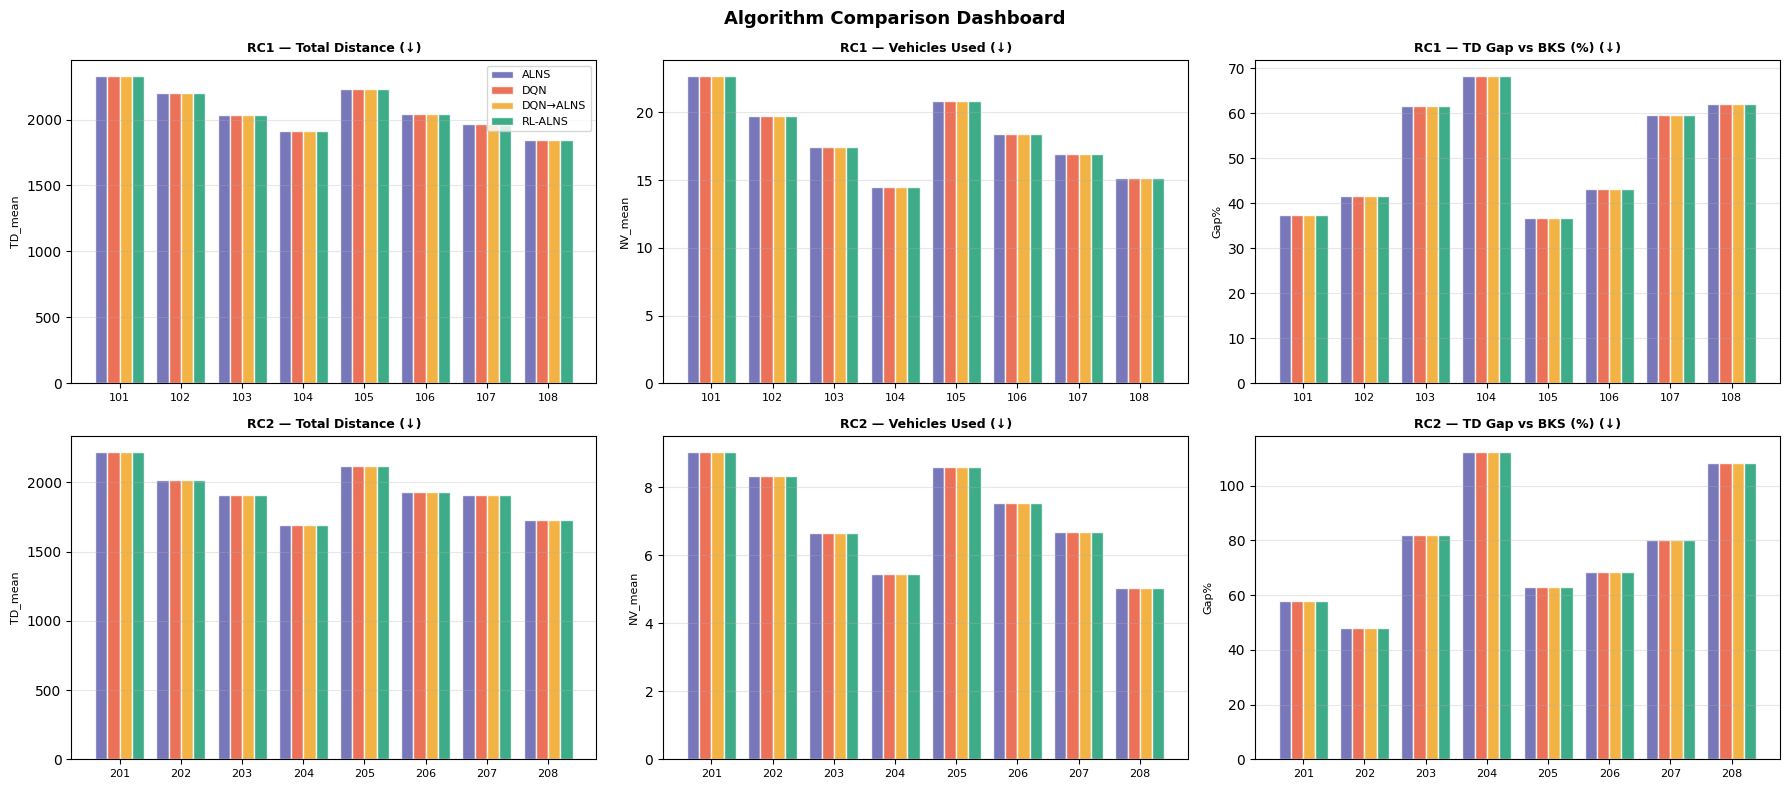

In [17]:
# ── 17. Results Analysis & Dashboard ─────────────────────────────────────────
result_path = os.path.join(OUTPUT_DIR, 'benchmark.csv')
if os.path.exists(result_path):
    df = pd.read_csv(result_path)
    print_paper_table(df)
    per_instance_table(df, 'RC1')
    per_instance_table(df, 'RC2')
    plot_dashboard(df)
else:
    print('Run cell 16 first.')

## 📋 Changes vs Previous Version

### DQN (constructive) — improved but not focus
| | Before | After |
|---|---|---|
| State dim | 9 (unnormalized features) | **13** (all normalized 0–1, +4 TW features) |
| Reward | `-distance` only | `-distance` + **vehicle penalty** (−10/n per new route) |
| Epsilon decay | Linear (too fast) | **Exponential** (smooth exploration) |
| Network | 256→128→64 (no norm) | 128→128 + **LayerNorm** (stable) |

### DQN→ALNS — architecture fix
| | Before | After |
|---|---|---|
| Warm-start | Always DQN (even if 27+ veh) | **Fallback**: DQN or greedy, whichever dominates |
| Effect | ALNS starts from bad point | ALNS always starts from best available |

### RL-ALNS — main contribution ✅
| | Before (DQNALNSAgent) | After |
|---|---|---|
| State | 8D **raw** (cost=1000+, n=100) | **14D normalized** (all 0–1, +TW features) |
| Operators | 3×2=6 combos | **5×4=20 combos** (more search diversity) |
| Network | Basic DQN | **Dueling Double DQN** (less overestimation) |
| Reward | `cost_before - cost_after` | **Hierarchical**: vehicle reduction > cost reduction |
| Acceptance | Random 10% | **Simulated Annealing** (proper exploration) |
| ALNS weights | Not updated | **Dual update**: RL selects + ALNS adaptive weights both run |

### Experiment
- `n_runs=5` with mean ± std (was 1 run)
- Results saved incrementally (checkpoint/resume)
- Paper-style table with BKS comparison